BTCUSDT-pd-2022-09.csv


/tmp/ipykernel_8951/3856913223.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


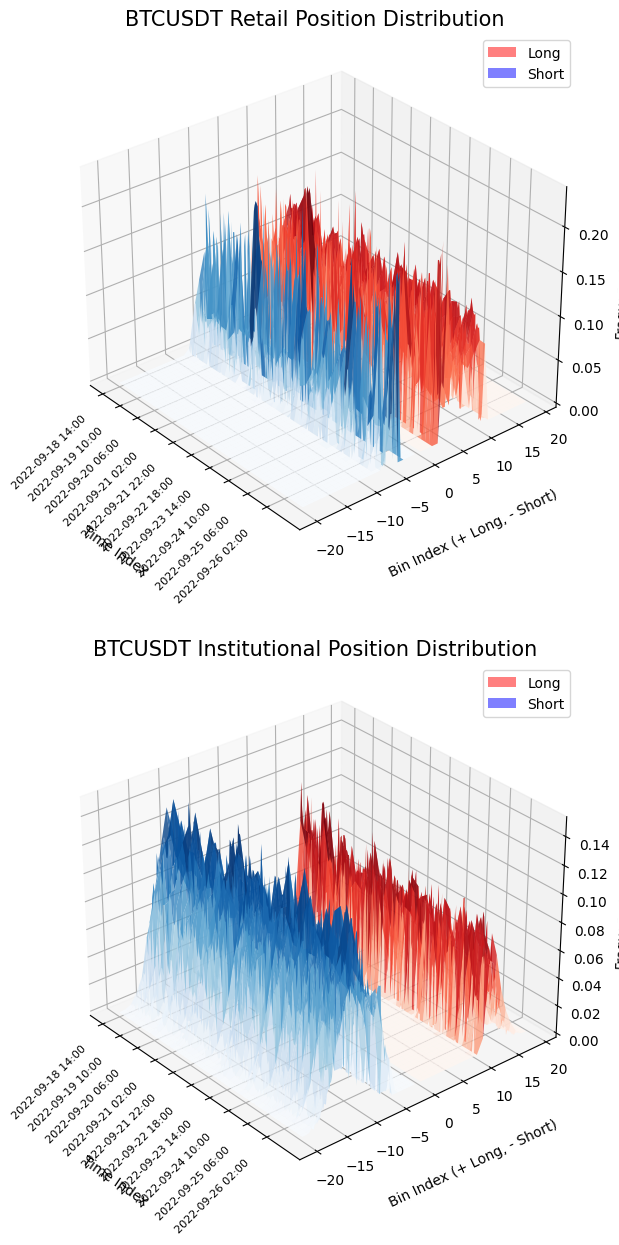

BTCUSDT-pd-2024-11.csv


/tmp/ipykernel_8951/3856913223.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


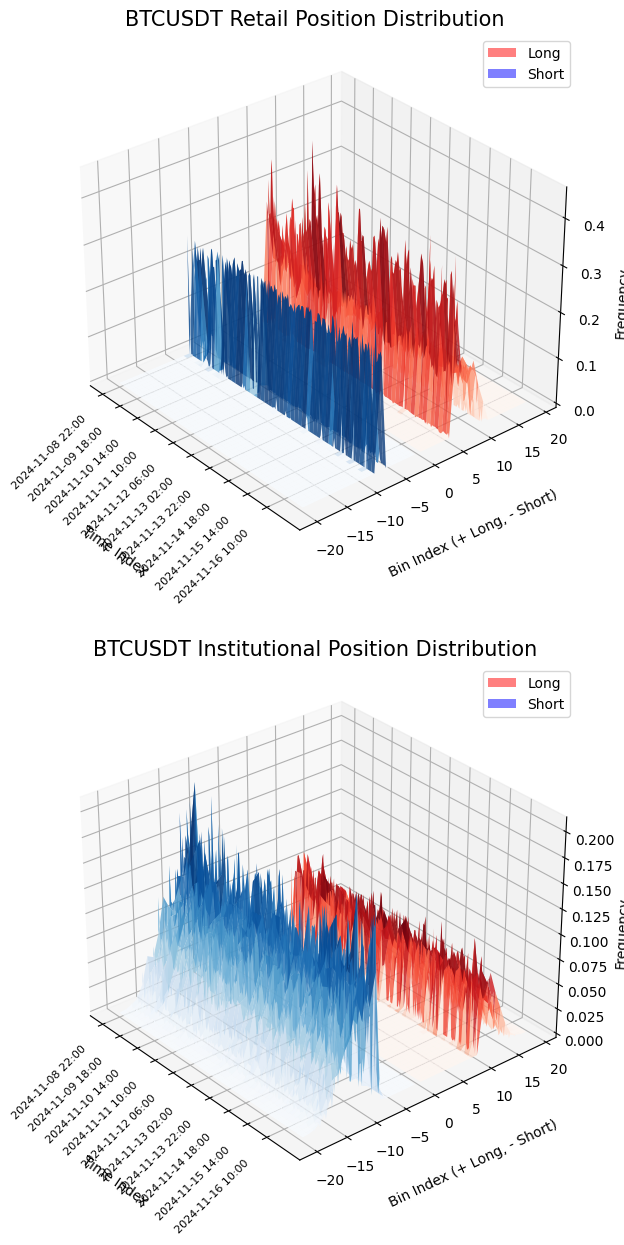

BTCUSDT-pd-2024-08.csv


/tmp/ipykernel_8951/3856913223.py:89: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(pad=4.0)


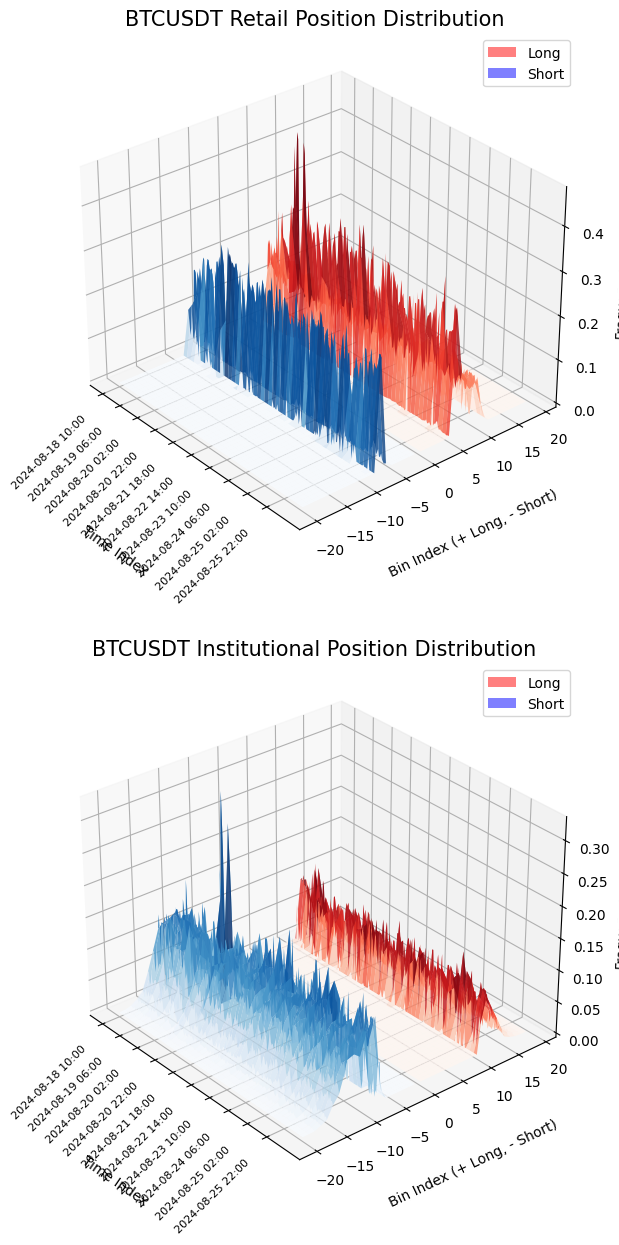

In [3]:
import os 
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# position distribution 디렉토리 내의 파일 탐색
file_path = "../data/binance/futures/um/monthly/position_distribution/3600000"
available_file_path = os.listdir(file_path)[:3]

for file in available_file_path:
    print(file)
    csv_path = os.path.join(file_path, file)
    df = pd.read_csv(csv_path, index_col=0)
    
    # JSON 형태로 저장된 리스트 컬럼 변환
    df['retail_long'] = df['retail_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['retail_short'] = df['retail_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_long'] = df['institutional_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_short'] = df['institutional_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)

    # 임의의 시작 index로부터 순서대로 1000개 row 추출
    n_samples = 200
    start_idx = np.random.randint(0, len(df) - n_samples)
    data_to_plot = df.iloc[start_idx:start_idx+n_samples]

    # 그래프 생성
    fig = plt.figure(figsize=(24, 15))

    # 개인(retail)과 기관(institutional) 그래프 생성
    categories = ["retail", "institutional"]
    for idx, category in enumerate(categories):
        ax = fig.add_subplot(2, 1, idx + 1, projection="3d")

        # 데이터 준비
        x_times = np.arange(len(data_to_plot))

        # long과 short 데이터를 하나의 그래프에 표시하기 위해 bin 인덱스 조정
        long_bins = np.arange(len(data_to_plot.iloc[0][f"{category}_long"]))
        short_bins = -np.arange(len(data_to_plot.iloc[0][f"{category}_short"]))[::-1] - 1

        # Long 데이터 처리
        X_long, Y_long = np.meshgrid(x_times, long_bins)
        Z_long = np.zeros((len(long_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_long[:, i] = data_to_plot.iloc[i][f"{category}_long"]

        # Short 데이터 처리
        X_short, Y_short = np.meshgrid(x_times, short_bins)
        Z_short = np.zeros((len(short_bins), len(x_times)))
        for i, time_idx in enumerate(x_times):
            Z_short[:, i] = data_to_plot.iloc[i][f"{category}_short"]

        # 3D 표면 그래프 그리기
        surf_long = ax.plot_surface(
            X_long, Y_long, Z_long, cmap="Reds", edgecolor="none", alpha=0.8, label="Long"
        )
        surf_short = ax.plot_surface(
            X_short, Y_short, Z_short, cmap="Blues", edgecolor="none", alpha=0.8, label="Short"
        )

        # 그래프 제목 및 레이블 설정
        ax.set_title(f"BTCUSDT {category.capitalize()} Position Distribution", fontsize=15)
        ax.set_xlabel("Time Index", labelpad=35)
        ax.set_ylabel("Bin Index (+ Long, - Short)", labelpad=15)
        ax.set_zlabel("Frequency")

        # 실제 시간 표시를 위한 눈금 설정
        time_labels = [str(t)[:16] for t in data_to_plot.index]  # 날짜와 시간(시:분)까지 표시
        tick_interval = max(1, len(x_times) // 10)
        selected_ticks = x_times[::tick_interval]
        selected_labels = [time_labels[i] for i in selected_ticks]
        ax.set_xticks(selected_ticks)
        ax.set_xticklabels(selected_labels, rotation=45, ha="right", fontsize=8)

        # x축 라벨이 더 잘 보이도록 뷰 각도 조정
        ax.view_init(elev=30, azim=-40)

        # 범례 추가
        long_proxy = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
        short_proxy = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
        ax.legend([long_proxy, short_proxy], ["Long", "Short"], loc="upper right")

    plt.tight_layout(pad=4.0)
    plt.show()

In [29]:
# position distribution 디렉토리 내의 파일 탐색
file_path = "../data/binance/futures/um/monthly/position_distribution/3600000"
available_file_path = os.listdir(file_path)

n_samples = 0
for file in available_file_path:
    csv_path = os.path.join(file_path, file)
    df = pd.read_csv(csv_path, index_col=0)
    
    # JSON 형태로 저장된 리스트 컬럼 변환
    df['retail_long'] = df['retail_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['retail_short'] = df['retail_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_long'] = df['institutional_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_short'] = df['institutional_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)
    
    # df 내부 데이터에서 nan이 하나라도 있는지 체크하고, 있다면, 파일명과 nan 갯수, nan이 해당하는 날짜 출력
    nan_count = df.isna().sum().sum()
    if nan_count > 0:
        print(f"파일명: {file}, NaN 개수: {nan_count}")
        print(df.loc[df.isna().any(axis=1)].index)
        
    n_samples += len(df) - nan_count

print(f"총 샘플 수: {n_samples}")

파일명: BTCUSDT-pd-2022-09.csv, NaN 개수: 96
DatetimeIndex(['2022-09-10 01:00:00', '2022-09-10 02:00:00',
               '2022-09-10 03:00:00', '2022-09-10 04:00:00',
               '2022-09-10 05:00:00', '2022-09-10 06:00:00',
               '2022-09-10 07:00:00', '2022-09-10 08:00:00',
               '2022-09-10 09:00:00', '2022-09-10 10:00:00',
               '2022-09-10 11:00:00', '2022-09-10 12:00:00',
               '2022-09-10 13:00:00', '2022-09-10 14:00:00',
               '2022-09-10 15:00:00', '2022-09-10 16:00:00',
               '2022-09-10 17:00:00', '2022-09-10 18:00:00',
               '2022-09-10 19:00:00', '2022-09-10 20:00:00',
               '2022-09-10 21:00:00', '2022-09-10 22:00:00',
               '2022-09-10 23:00:00', '2022-09-11 00:00:00'],
              dtype='datetime64[ns]', freq=None)
파일명: BTCUSDT-pd-2022-08.csv, NaN 개수: 288
DatetimeIndex(['2022-08-28 01:00:00', '2022-08-28 02:00:00',
               '2022-08-28 03:00:00', '2022-08-28 04:00:00',
               

In [22]:
import seaborn as sns
from sklearn.mixture import GaussianMixture

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# position distribution 디렉토리 내의 파일 탐색
available_file_path = os.listdir(file_path)[:3]

for file in available_file_path:
    print(file)
    df = pd.read_csv(os.path.join(file_path, file), index_col=0)
    
    # 날짜/시간 열을 인덱스로 설정
    df.index = pd.to_datetime(df.index)
    
    # JSON 형태로 저장된 리스트 컬럼 변환
    df['retail_long'] = df['retail_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['retail_short'] = df['retail_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_long'] = df['institutional_long'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    df['institutional_short'] = df['institutional_short'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

    
    # 리지 플롯을 위한 데이터 준비
    plot_data = []
    
    # 각 시간별로 데이터 처리
    for idx, row in df.iterrows():
        print(idx)
        time_str = idx.strftime('%Y-%m-%d %H:%M')
        
        # 개인 투자자 데이터 (long + short)
        retail_data = row['retail_long'] + [-x for x in row['retail_short']]  # short은 음수로 변환
        
        # 기관 투자자 데이터 (long + short)
        institutional_data = row['institutional_long'] + [-x for x in row['institutional_short']]
        
        # 각 데이터 포인트를 DataFrame에 추가
        for value in retail_data:
            plot_data.append({'time': time_str, 'value': value, 'type': 'retail'})
        
        for value in institutional_data:
            plot_data.append({'time': time_str, 'value': value, 'type': 'institutional'})
    
    # 데이터프레임 생성
    plot_df = pd.DataFrame(plot_data)
    
    # 리지 플롯 생성
    g = sns.FacetGrid(data=plot_df, row="time", aspect=6, height=1.8)
    
    # 밀도 그래프 그리기
    g.map_dataframe(sns.kdeplot, "value",
                    bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5,
                    hue="type", hue_order=['retail', 'institutional'], 
                    palette=['tomato', 'turquoise'], multiple='stack')
    
    g.map(plt.axhline, y=0, lw=2, clip_on=False, color='black')
    
    # 라벨 함수 정의
    def label(x, color):
        ax = plt.gca()
        ax.text(0, .2, x.iloc[0], fontweight="bold", color='black',
                ha="left", va="center", transform=ax.transAxes)
    
    g.map(label, "time")
    
    # 제목 및 레이블 설정
    plt.suptitle(f"BTCUSDT 포지션 분포 변화 - {file}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

BTCUSDT-pd-2022-09.csv
2022-09-02 01:00:00
2022-09-02 02:00:00
2022-09-02 03:00:00
2022-09-02 04:00:00
2022-09-02 05:00:00
2022-09-02 06:00:00
2022-09-02 07:00:00
2022-09-02 08:00:00
2022-09-02 09:00:00
2022-09-02 10:00:00
2022-09-02 11:00:00
2022-09-02 12:00:00
2022-09-02 13:00:00
2022-09-02 14:00:00
2022-09-02 15:00:00
2022-09-02 16:00:00
2022-09-02 17:00:00
2022-09-02 18:00:00
2022-09-02 19:00:00
2022-09-02 20:00:00
2022-09-02 21:00:00
2022-09-02 22:00:00
2022-09-02 23:00:00
2022-09-03 00:00:00
2022-09-03 01:00:00
2022-09-03 02:00:00
2022-09-03 03:00:00
2022-09-03 04:00:00
2022-09-03 05:00:00
2022-09-03 06:00:00
2022-09-03 07:00:00
2022-09-03 08:00:00
2022-09-03 09:00:00
2022-09-03 10:00:00
2022-09-03 11:00:00
2022-09-03 12:00:00
2022-09-03 13:00:00
2022-09-03 14:00:00
2022-09-03 15:00:00
2022-09-03 16:00:00
2022-09-03 17:00:00
2022-09-03 18:00:00
2022-09-03 19:00:00
2022-09-03 20:00:00
2022-09-03 21:00:00
2022-09-03 22:00:00
2022-09-03 23:00:00
2022-09-04 00:00:00
2022-09-04 01:00:

TypeError: 'float' object is not iterable

In [23]:
df

,retail_long,retail_short,institutional_long,institutional_short
2022-09-02 01:00:00,"[0.0, 0.0, 0.0, 0.0, 0.1876566628277217, 0.083...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0007013516959959194, 0.00204029584289722, 0..."
2022-09-02 02:00:00,"[0.0, 0.0, 0.0, 0.0, 0.16572014513330177, 0.07...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.000386458494357706, 0.0005410418921007883, ..."
2022-09-02 03:00:00,"[0.0, 0.0, 0.0, 0.0, 0.15716911764705882, 0.07...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0002580312217778351, 0.0012256483034447168,..."
2022-09-02 04:00:00,"[0.0, 0.0, 0.0, 0.00030828041186263023, 0.2152...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.000408843601597635, 0.00371104192..."
2022-09-02 05:00:00,"[0.0, 0.0, 0.0, 0.0, 0.17588377723970944, 0.06...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.930723337113555e-05, 0.0002958434002268133,..."
...,...,...,...,...
2022-09-30 20:00:00,"[0.0, 0.0, 0.0, 0.13619783150109432, 0.0363261...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7.415280421187928e-05, 0.00019774081123167807..."
2022-09-30 21:00:00,"[0.0, 0.0, 0.0, 0.10970066745833504, 0.0389418...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 4.1235412972660925e-05, 0.00018555935837..."
2022-09-30 22:00:00,"[0.0, 0.0, 0.0, 0.09863167760074977, 0.0384254...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7.719921256803181e-05, 0.0001929980314200795,..."
2022-09-30 23:00:00,"[0.0, 0.0, 0.0, 0.0, 0.11458192624611643, 0.06...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.00039154267815191856, 0.0007474905673809354..."
